# 09. H5 — 버스정류장 50m 이내 횡단보도와 음향신호기 (그룹 만들기와 시각 확인)

> **검정은 하지 않는다.** 이 노트북은 그룹을 만들고, 그룹별 음향신호기 매칭 비율을 그림으로 확인하는 데까지만 한다.
> 아래 비율의 차이가 우연인지는 아직 모른다. 카이제곱 검정과 자치구 통제는 다음 단계다.

방향은 `08_서울전체_가설검증_방향.ipynb` 2절을 따른다.

- 서울 횡단보도를 "버스정류장 50m 이내"와 "그 외"로 나눈다. 30m·100m는 민감도용이다.
- 버스정류소는 마을버스를 포함한 전체(한강선착장 8개 제외)를 쓴다.
- **보행등 유무 열은 그룹 비교에 쓰지 않는다.** 아래 3절에서 매칭 규칙을 점검할 때만 참고로 본다.
- 결과 변수는 "횡단보도 근처에 음향신호기가 매칭되었는가"다. 신호기 좌표가 없는 21%는 "위치 모름"이라 매칭에서 빠진다.
- 계산은 `h5_master.py`가 하고, 이 노트북은 결과를 불러 그림으로 보여준다. 마스터 표는 `data/h5/crosswalk_master.csv`로 저장된다.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from IPython.display import display
from scipy.spatial import cKDTree
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'h5_master.py').exists():
    PROJECT_DIR = PROJECT_DIR / 'DartB_TOYPROJECT'
sys.path.insert(0, str(PROJECT_DIR))
import h5_master as H

FIG_DIR = PROJECT_DIR / 'figures' / 'h5'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 색: 정류장 근처 = 파랑, 그 외 = 주황 (두 색은 색각 이상 검증 통과). 글자는 시리즈 색이 아니라 텍스트 색을 쓴다.
BLUE, ORANGE, INK, MUTED, GRID, SURFACE = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e', '#e5e5e2', '#fcfcfb'
NEAR, OTHER = BLUE, ORANGE
rcParams.update({
    'font.family': 'Malgun Gothic', 'axes.unicode_minus': False,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#c9c8c2',
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'axes.titlecolor': INK, 'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.7, 'axes.axisbelow': True,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE, 'figure.dpi': 110,
})

def save(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches='tight')
print('준비 완료. 그림 저장 위치:', FIG_DIR)

준비 완료. 그림 저장 위치: C:\Users\kjyil\Documents\python_study\DartB_TOYPROJECT\figures\h5


## 1. 횡단보도 마스터 표 만들기

횡단보도 1행 = 1개인 표에 정류소 거리와 음향신호기 매칭 여부를 붙인다.

- 횡단보도: `서울시_교차로_및_횡단보도_시설위치정보_20260824.csv`. 좌표가 없는 1행과, 같은 교차로 중심에서 1,000m 넘게 떨어진 4행(06 3-0-3에서 위치 오류로 판단)은 좌표를 비우고 그룹에서 뺀다. 행은 지우지 않는다.
- 음향신호기: `음향신호기_현황.csv`. 좌표가 있는 신호기만 매칭에 쓴다.
- 버스정류소: `서울시버스정류소위치정보(20260902).csv`(xlsx를 변환한 파일). 한강선착장 8개는 제외.

In [2]:
m, aud, bus = H.build_master()
path = H.save_master(m)
ok = m['좌표상태'] == '정상'
d = m[ok].copy()

# 0/1로 저장된 열을 참/거짓으로
for c in [c for c in d.columns if c.startswith(('정류장근처_', '음향_'))]:
    d[c] = d[c].astype(bool)

status = pd.DataFrame([
    ['횡단보도', f'{len(m):,}행', f"좌표 정상 {int(ok.sum()):,}개 / 위치 이상 {int((m['좌표상태'] == '위치이상').sum())}개 / 좌표 없음 {int((m['좌표상태'] == '결측').sum())}개"],
    ['음향신호기', f'{len(aud):,}행', f"좌표 있음 {int((~aud['좌표결측']).sum()):,}개 ({(~aud['좌표결측']).mean() * 100:.1f}%) / 좌표 없음(위치 모름) {int(aud['좌표결측'].sum()):,}개 ({aud['좌표결측'].mean() * 100:.1f}%)"],
    ['버스정류소', f'{len(bus):,}개 사용', ' / '.join(f'{k} {v:,}' for k, v in bus['정류소타입'].value_counts().items())],
], columns=['데이터', '규모', '내용'])
display(status)
print('저장:', path)

,데이터,규모,내용
0,횡단보도,"21,776행","좌표 정상 21,771개 / 위치 이상 4개 / 좌표 없음 1개"
1,음향신호기,"21,451행","좌표 있음 16,847개 (78.5%) / 좌표 없음(위치 모름) 4,604개 (2..."
2,버스정류소,"11,228개 사용","일반차로 6,251 / 마을버스 4,175 / 중앙차로 405 / 가로변시간 256..."


저장: C:\Users\kjyil\Documents\python_study\DartB_TOYPROJECT\data\h5\crosswalk_master.csv


## 2. 그룹 만들기

횡단보도마다 가장 가까운 버스정류소까지의 거리를 구하고, **50m 이내이면 "정류장 근처", 아니면 "그 외"** 로 한다. 30m·100m 기준과, 마을버스를 뺀 50m 기준도 함께 만들어 둔다(민감도용).

In [3]:
rows = []
for r in H.BUS_GROUP_M:
    n = int(d[f'정류장근처_{r}m'].sum())
    rows.append([f'{r}m 이내' + (' (기본)' if r == 50 else ''), n, len(d) - n, f'{n / len(d) * 100:.1f}%'])
n = int(d['정류장근처_50m_마을버스제외'].astype(bool).sum())
rows.append(['50m 이내, 마을버스 정류소 제외', n, len(d) - n, f'{n / len(d) * 100:.1f}%'])
groups = pd.DataFrame(rows, columns=['기준', '정류장 근처', '그 외', '근처 비율'])
display(groups)
print('가장 가까운 정류소까지 거리(m):', d['최근접정류소_m'].describe(percentiles=[.25, .5, .75, .9]).round(1).to_dict())
print('50m 안 정류소 수별 횡단보도:', d['정류소수_50m'].astype(int).value_counts().sort_index().to_dict())

,기준,정류장 근처,그 외,근처 비율
0,30m 이내,4903,16868,22.5%
1,50m 이내 (기본),9716,12055,44.6%
2,100m 이내,16567,5204,76.1%
3,"50m 이내, 마을버스 정류소 제외",7119,14652,32.7%


가장 가까운 정류소까지 거리(m): {'count': 21771.0, 'mean': 74.6, 'std': 64.4, 'min': 0.6, '25%': 31.9, '50%': 56.1, '75%': 97.0, '90%': 153.4, 'max': 1149.4}
50m 안 정류소 수별 횡단보도: {0: 12055, 1: 5180, 2: 3683, 3: 647, 4: 170, 5: 32, 6: 4}


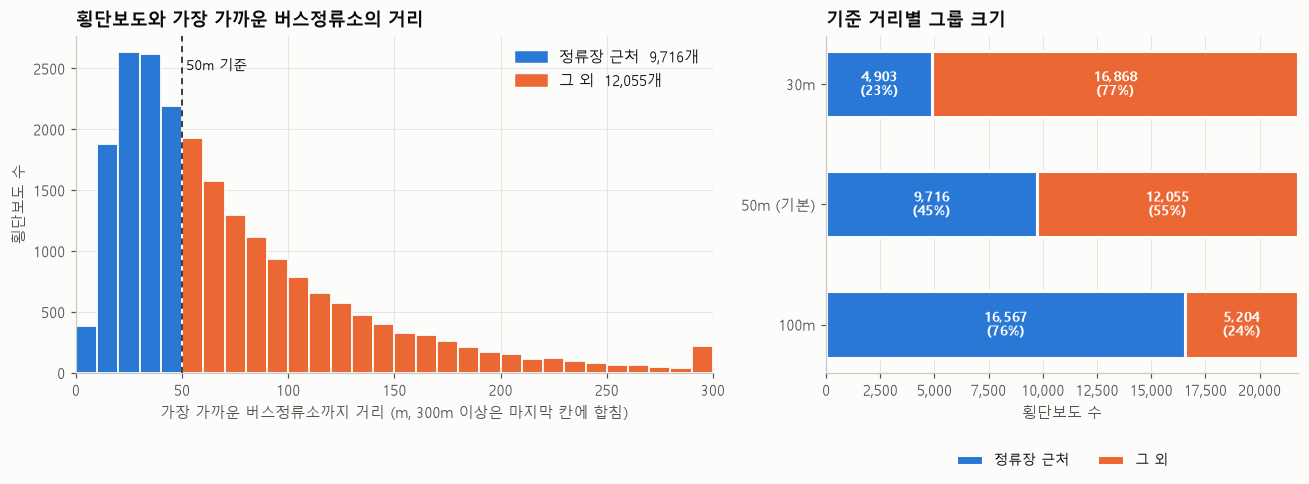

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={'width_ratios': [1.35, 1]})

# (a) 가장 가까운 정류소까지 거리 분포
edges = np.arange(0, 310, 10)
cnt, _ = np.histogram(d['최근접정류소_m'].clip(upper=299.9), bins=edges)
colors = [NEAR if e < 50 else OTHER for e in edges[:-1]]
ax1.bar(edges[:-1], cnt, width=10, align='edge', color=colors, edgecolor=SURFACE, linewidth=1.2)
ax1.axvline(50, color=INK, linewidth=1, linestyle=(0, (4, 3)))
ax1.text(52, cnt.max() * 0.98, '50m 기준', fontsize=9, color=INK, va='top')
n_near, n_other = int(d['정류장근처_50m'].sum()), int((~d['정류장근처_50m']).sum())
ax1.legend(handles=[Patch(color=NEAR, label=f'정류장 근처  {n_near:,}개'), Patch(color=OTHER, label=f'그 외  {n_other:,}개')], loc='upper right', frameon=False, fontsize=10)
ax1.set_xlim(0, 300); ax1.set_xlabel('가장 가까운 버스정류소까지 거리 (m, 300m 이상은 마지막 칸에 합침)'); ax1.set_ylabel('횡단보도 수')
ax1.set_title('횡단보도와 가장 가까운 버스정류소의 거리')

# (b) 기준 거리별 그룹 크기
labels = ['30m', '50m (기본)', '100m']
near = [int(d[f'정류장근처_{r}m'].sum()) for r in H.BUS_GROUP_M]
oth = [len(d) - x for x in near]
y = np.arange(len(labels))[::-1]
ax2.barh(y, near, color=NEAR, edgecolor=SURFACE, linewidth=2, height=0.55, label='정류장 근처')
ax2.barh(y, oth, left=near, color=OTHER, edgecolor=SURFACE, linewidth=2, height=0.55, label='그 외')
for yi, a, b in zip(y, near, oth):
    ax2.text(a / 2, yi, f'{a:,}\n({a / (a + b) * 100:.0f}%)', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax2.text(a + b / 2, yi, f'{b:,}\n({b / (a + b) * 100:.0f}%)', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax2.set_yticks(y); ax2.set_yticklabels(labels); ax2.set_xlim(0, len(d)); ax2.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{int(v):,}')); ax2.set_xlabel('횡단보도 수'); ax2.grid(axis='y', visible=False)
ax2.set_title('기준 거리별 그룹 크기'); ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False, fontsize=9)
plt.tight_layout(); save(fig, '01_그룹_만들기.png'); plt.show()

### 2-1. 서울 지도에서 보기

왼쪽은 횡단보도를 그룹별로 찍은 지도, 오른쪽은 지역별로 정류장 근처 횡단보도의 비중을 본 지도다(가로세로 약 1km 칸, 횡단보도 10개 이상인 칸만). 자치구에 따라 비중이 크게 다른지 눈으로 확인하려는 것이다.

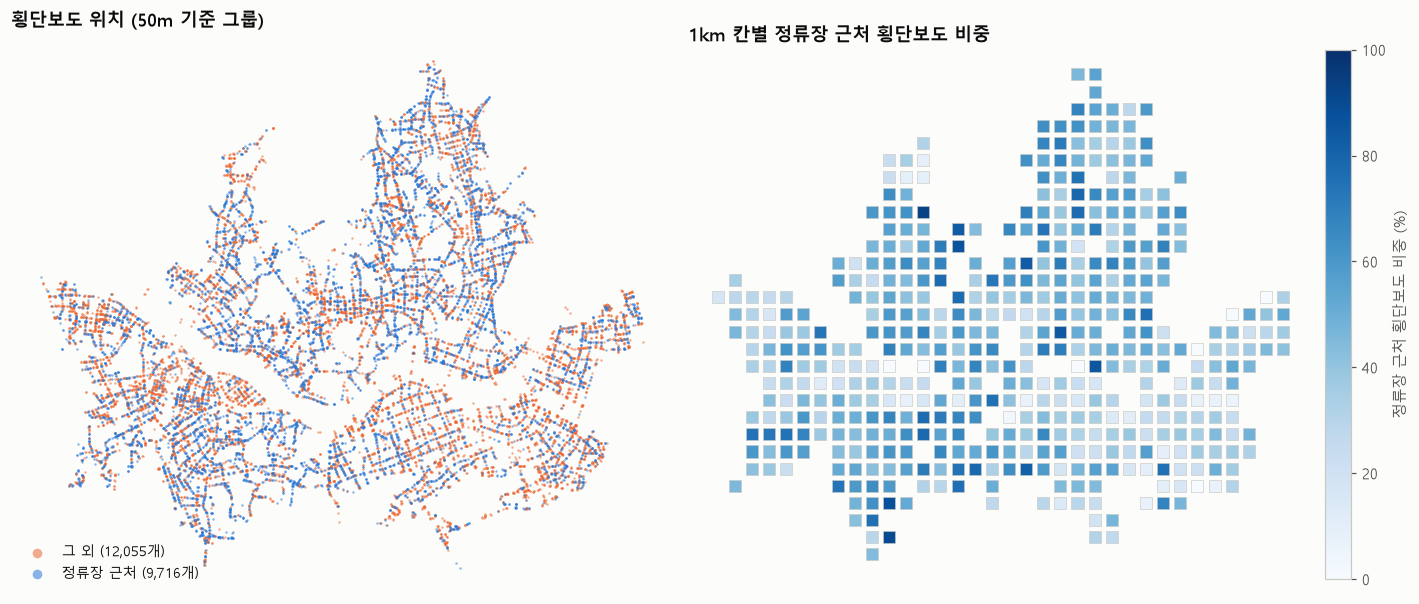

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.6))
far = d[~d['정류장근처_50m']]; nr = d[d['정류장근처_50m']]
ax1.scatter(far['x'], far['y'], s=2.5, color=OTHER, alpha=0.55, linewidths=0, label=f'그 외 ({len(far):,}개)')
ax1.scatter(nr['x'], nr['y'], s=2.5, color=NEAR, alpha=0.55, linewidths=0, label=f'정류장 근처 ({len(nr):,}개)')
ax1.set_aspect('equal'); ax1.set_xticks([]); ax1.set_yticks([]); ax1.grid(False)
for s in ax1.spines.values(): s.set_visible(False)
ax1.set_title('횡단보도 위치 (50m 기준 그룹)')
lg = ax1.legend(loc='lower left', frameon=False, fontsize=9, markerscale=4)

cell = 1000
gx = (d['x'] // cell).astype(int); gy = (d['y'] // cell).astype(int)
g = d.assign(gx=gx, gy=gy).groupby(['gx', 'gy'])['정류장근처_50m'].agg(['mean', 'size']).reset_index()
g = g[g['size'] >= 10]
sc = ax2.scatter(g['gx'] * cell + cell / 2, g['gy'] * cell + cell / 2, c=g['mean'] * 100, cmap='Blues', vmin=0, vmax=100,
                 marker='s', s=62, edgecolors='#c9c8c2', linewidths=0.4)
ax2.set_aspect('equal'); ax2.set_xticks([]); ax2.set_yticks([]); ax2.grid(False)
for s in ax2.spines.values(): s.set_visible(False)
cb = plt.colorbar(sc, ax=ax2, fraction=0.04, pad=0.02); cb.set_label('정류장 근처 횡단보도 비중 (%)', color=MUTED)
ax2.set_title('1km 칸별 정류장 근처 횡단보도 비중')
plt.tight_layout(); save(fig, '02_서울_지도.png'); plt.show()

## 3. 음향신호기 매칭 규칙 점검

결과 변수를 만들기 전에, 06 3-4-1에서 의심한 문제를 확인한다. 06의 규칙은 "횡단보도에서 가장 가까운 신호기가 15m 이내"였는데, 보행등이 없는 횡단보도의 27%에도 신호기가 걸렸다. 이웃 횡단보도의 신호기가 걸린 것일 수 있다.

- **단순 규칙(06):** 횡단보도에서 가장 가까운 신호기까지 거리가 R m 이내이면 매칭.
- **배정 규칙(이 노트북의 기본):** 신호기를 **가장 가까운 횡단보도 하나에만** 배정하고, 배정된 신호기가 R m 이내에 하나라도 있으면 그 횡단보도를 매칭으로 본다.

보행등 유무는 그룹 비교에는 쓰지 않고, 여기서 규칙이 이상한지 보는 참고용으로만 쓴다. 보행등이 없는 횡단보도에는 음향신호기가 거의 없어야 하기 때문이다.

In [6]:
R = 15
tab = []
for name, col in [('단순 규칙 (06 방식)', f'음향_단순_{R}m'), ('배정 규칙 (기본)', f'음향_배정_{R}m')]:
    tab.append({'규칙': name, '매칭된 횡단보도 수': int(d[col].sum()), '전체 %': d[col].mean() * 100,
                '보행등 있음 %': d.loc[d['보행등유무'] == '유', col].mean() * 100, '보행등 없음 %': d.loc[d['보행등유무'] == '무', col].mean() * 100})
rule = pd.DataFrame(tab).set_index('규칙').round(1)
display(rule)

# 신호기 쪽: 좌표 있는 신호기 중 R m 안에 횡단보도가 있는 신호기
axy = aud.loc[~aud['좌표결측'], ['x', 'y']].to_numpy()
dd, _ = cKDTree(d[['x', 'y']].to_numpy()).query(axy)
print(f'좌표 있는 신호기 {len(axy):,}개 중 가장 가까운 횡단보도가 {R}m 이내인 신호기: {int((dd <= R).sum()):,}개 ({(dd <= R).mean() * 100:.1f}%)')
print(f'나머지 {int((dd > R).sum()):,}개는 어떤 횡단보도에도 {R}m 안에 없어서 매칭에 쓰이지 않는다(횡단보도 좌표 부정확, 다른 시설의 신호기 등이 원인일 수 있으나 확인하지 않았다).')
print('가장 가까운 횡단보도까지 거리 분위(m):', pd.Series(dd).quantile([.5, .75, .9]).round(1).to_dict())

,매칭된 횡단보도 수,전체 %,보행등 있음 %,보행등 없음 %
규칙,,,,
단순 규칙 (06 방식),11007,50.6,64.7,27.3
배정 규칙 (기본),8975,41.2,59.5,11.3


좌표 있는 신호기 16,847개 중 가장 가까운 횡단보도가 15m 이내인 신호기: 15,555개 (92.3%)
나머지 1,292개는 어떤 횡단보도에도 15m 안에 없어서 매칭에 쓰이지 않는다(횡단보도 좌표 부정확, 다른 시설의 신호기 등이 원인일 수 있으나 확인하지 않았다).
가장 가까운 횡단보도까지 거리 분위(m): {0.5: 9.0, 0.75: 11.6, 0.9: 14.2}


## 4. 그룹별 결과 (기술통계, 검정 아님)

결과 변수는 **배정 규칙 15m로 음향신호기가 매칭된 횡단보도인지**다. 보행등이 없는 횡단보도도 분모에 그대로 들어가 있어서, 비율은 "전체 횡단보도 중 매칭된 비율"이다(보행등이 있는 횡단보도 중 비율이 아니다).

### 4-1. 그룹별 매칭 비율

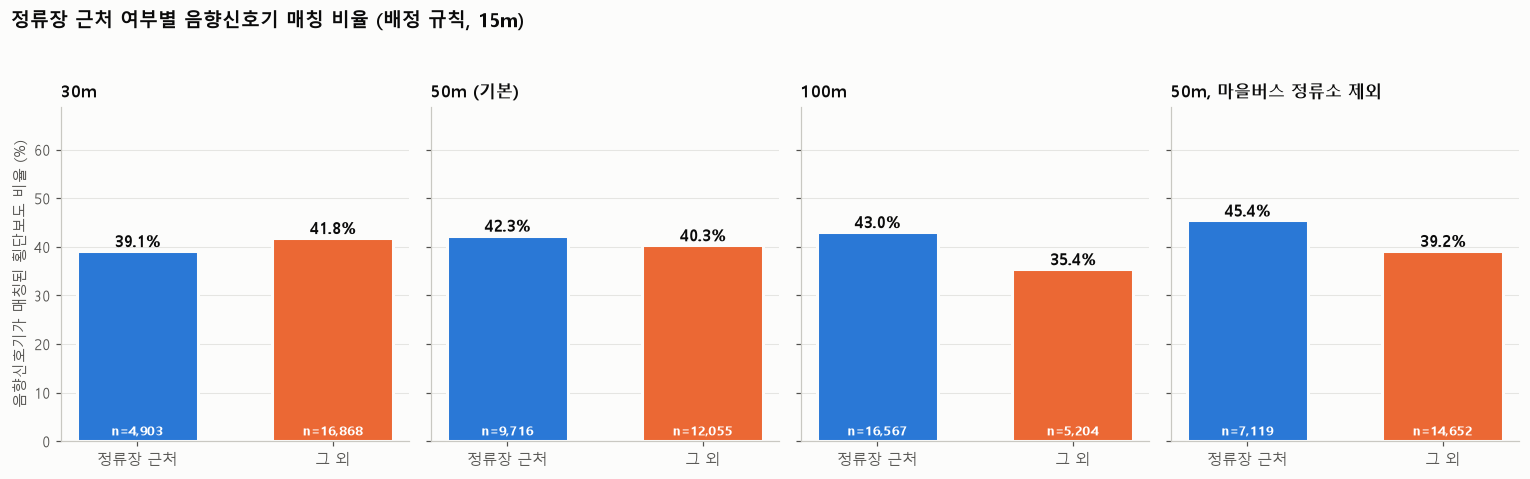

,근처 n,근처 매칭,근처 %,그 외 n,그 외 매칭,그 외 %,"차이(근처-그 외, %p)"
기준,,,,,,,
30m,4903,1919,39.1,16868,7056,41.8,-2.7
50m (기본),9716,4112,42.3,12055,4863,40.3,2.0
100m,16567,7132,43.0,5204,1843,35.4,7.6
"50m, 마을버스 정류소 제외",7119,3234,45.4,14652,5741,39.2,6.2


In [7]:
HIT = '음향_배정_15m'
panels = [('30m', '정류장근처_30m'), ('50m (기본)', '정류장근처_50m'), ('100m', '정류장근처_100m'), ('50m, 마을버스 정류소 제외', '정류장근처_50m_마을버스제외')]
fig, axes = plt.subplots(1, 4, figsize=(14, 4.4), sharey=True)
summary = []
for ax, (title, col) in zip(axes, panels):
    g = d[col].astype(bool)
    vals, ns, hits = [], [], []
    for flag in (True, False):
        s = d.loc[g == flag, HIT]
        vals.append(s.mean() * 100); ns.append(len(s)); hits.append(int(s.sum()))
    summary.append({'기준': title, '근처 n': ns[0], '근처 매칭': hits[0], '근처 %': vals[0], '그 외 n': ns[1], '그 외 매칭': hits[1], '그 외 %': vals[1]})
    bars = ax.bar([0, 1], vals, color=[NEAR, OTHER], edgecolor=SURFACE, linewidth=2, width=0.62)
    for x, v, n in zip([0, 1], vals, ns):
        ax.text(x, v + 0.8, f'{v:.1f}%', ha='center', fontsize=10.5, fontweight='bold')
        ax.text(x, 1.2, f'n={n:,}', ha='center', fontsize=8.5, color='white', fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['정류장 근처', '그 외']); ax.grid(axis='x', visible=False)
    ax.set_title(title, fontsize=11)
axes[0].set_ylabel('음향신호기가 매칭된 횡단보도 비율 (%)')
axes[0].set_ylim(0, max(s['근처 %'] for s in summary) * 1.25 + max(s['그 외 %'] for s in summary) * 0.05 + 10)
fig.suptitle('정류장 근처 여부별 음향신호기 매칭 비율 (배정 규칙, 15m)', x=0.01, ha='left', fontweight='bold', fontsize=12.5)
plt.tight_layout(rect=(0, 0, 1, 0.94)); save(fig, '03_그룹별_매칭비율.png'); plt.show()
tab3 = pd.DataFrame(summary).set_index('기준')
tab3['차이(근처-그 외, %p)'] = tab3['근처 %'] - tab3['그 외 %']
display(tab3.round(1))

### 4-2. 정류소까지 거리 구간별 매칭 비율

50m에서 그룹을 가르는 것이 자연스러운지, 아니면 거리가 멀어질수록 비율이 서서히 변하는지 본다. 구간별 횡단보도 수가 적으면 비율이 흔들리므로 수를 같이 적었다.

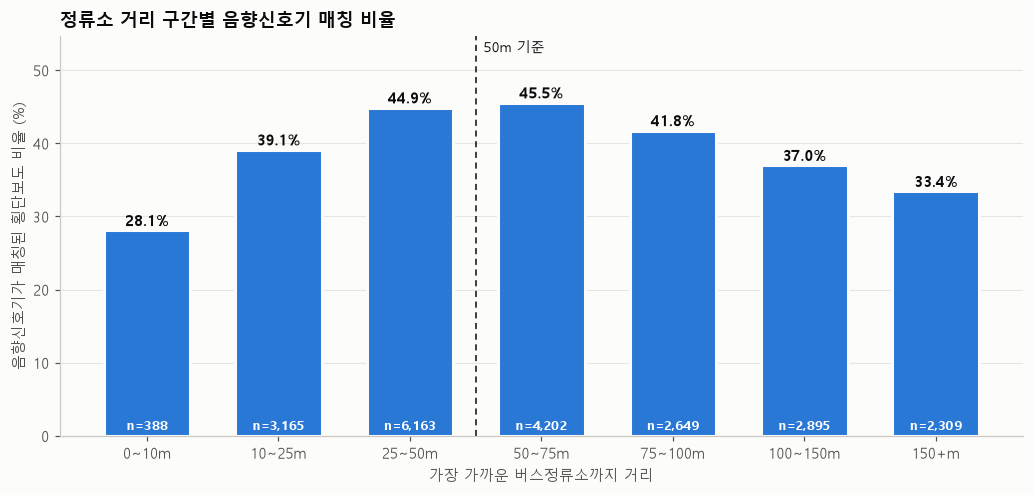

In [8]:
bins = [0, 10, 25, 50, 75, 100, 150, np.inf]
labels = ['0~10', '10~25', '25~50', '50~75', '75~100', '100~150', '150+']
cut = pd.cut(d['최근접정류소_m'], bins=bins, labels=labels, right=False)
bt = d.groupby(cut)[HIT].agg(['mean', 'size', 'sum'])
fig, ax = plt.subplots(figsize=(9.5, 4.6))
x = np.arange(len(labels))
ax.bar(x, bt['mean'] * 100, color=BLUE, edgecolor=SURFACE, linewidth=2, width=0.66)
for xi, (mean, n) in enumerate(zip(bt['mean'] * 100, bt['size'])):
    ax.text(xi, mean + 0.6, f'{mean:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.text(xi, 0.8, f'n={n:,}', ha='center', fontsize=8.5, color='white', fontweight='bold')
ax.set_ylim(0, bt['mean'].max() * 100 * 1.2)
ax.axvline(2.5, color=INK, linewidth=1, linestyle=(0, (4, 3)))
ax.text(2.56, ax.get_ylim()[1] * 0.99, '50m 기준', fontsize=9, va='top')
ax.set_xticks(x); ax.set_xticklabels([f'{l}m' for l in labels]); ax.grid(axis='x', visible=False)
ax.set_xlabel('가장 가까운 버스정류소까지 거리'); ax.set_ylabel('음향신호기가 매칭된 횡단보도 비율 (%)')
ax.set_title('정류소 거리 구간별 음향신호기 매칭 비율')
plt.tight_layout(); save(fig, '04_거리구간별_매칭비율.png'); plt.show()

### 4-3. 자치구별로 나눠서 보기

자치구마다 정류장 근처 횡단보도 비중이 28.7%(중구)~63.1%(동작구)로 크게 달랐다. 서울 전체 비율이 자치구 차이에 좌우될 수 있어서, 자치구 안에서 두 그룹을 비교해 본다. 점이 두 그룹의 비율이고, 오른쪽 숫자는 그 자치구에서 정류장 근처 횡단보도의 비중과 그룹별 횡단보도 수다. **자치구별 결과는 표본이 작아 검정 없이 방향만 본다.**

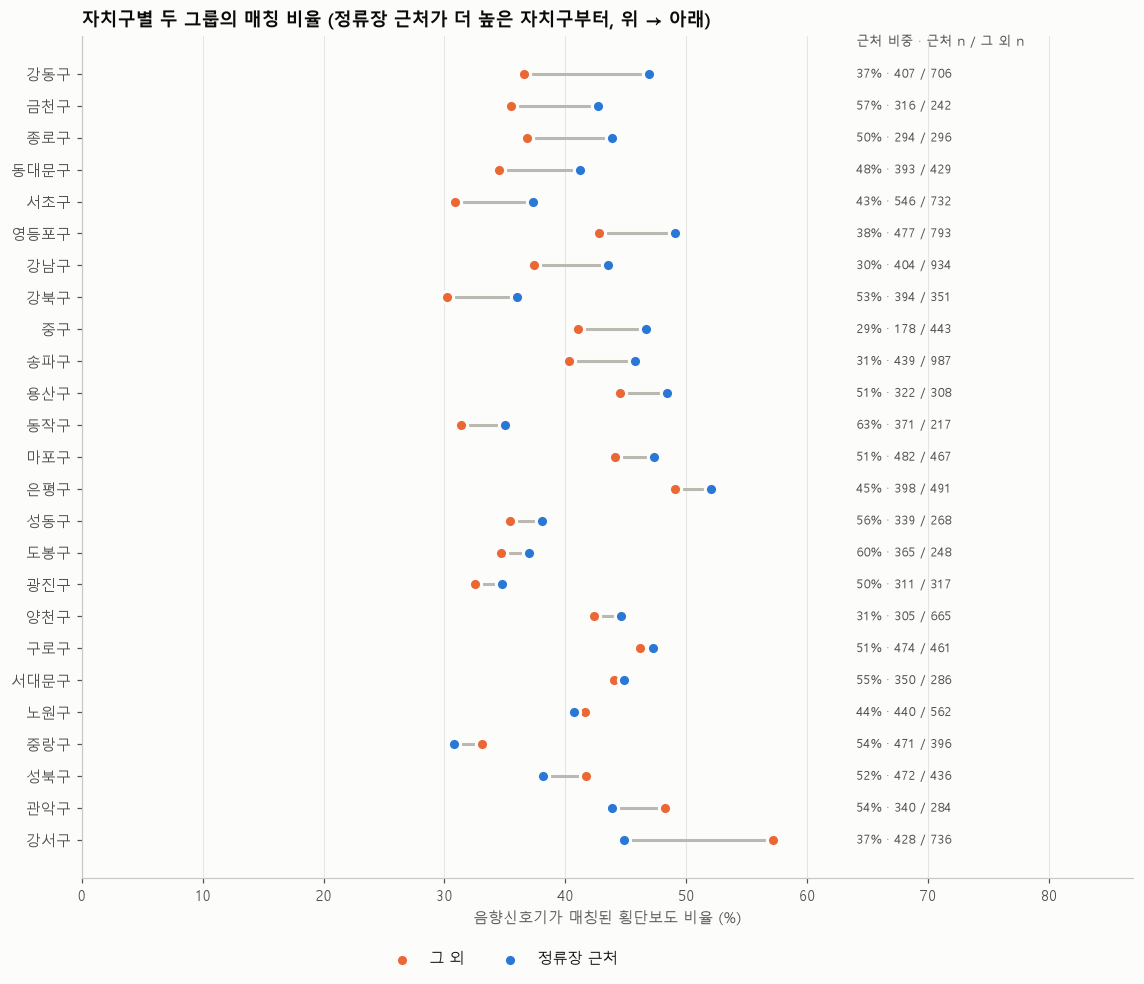

근처가 그 외보다 높은 자치구 20개 / 낮은 자치구 5개 / 같음 0개 (전체 25개)
한쪽 그룹이 50개 미만인 자치구: []


In [9]:
gu = d.groupby(['자치구', '정류장근처_50m'])[HIT].agg(['mean', 'size']).unstack()
gu.columns = [f'{a}_{"근처" if b else "그외"}' for a, b in gu.columns]
gu['근처비중'] = gu['size_근처'] / (gu['size_근처'] + gu['size_그외']) * 100
gu['차이'] = (gu['mean_근처'] - gu['mean_그외']) * 100
gu = gu.sort_values('차이')
fig, ax = plt.subplots(figsize=(10.5, 9))
y = np.arange(len(gu))
for yi, (a, b) in enumerate(zip(gu['mean_근처'] * 100, gu['mean_그외'] * 100)):
    ax.plot([a, b], [yi, yi], color='#b9b8b1', linewidth=2, zorder=1)
ax.scatter(gu['mean_그외'] * 100, y, s=64, color=OTHER, edgecolors=SURFACE, linewidths=2, zorder=3, label='그 외')
ax.scatter(gu['mean_근처'] * 100, y, s=64, color=NEAR, edgecolors=SURFACE, linewidths=2, zorder=3, label='정류장 근처')
ax.set_yticks(y); ax.set_yticklabels(gu.index); ax.grid(axis='y', visible=False)
xmax = max(gu['mean_근처'].max(), gu['mean_그외'].max()) * 100
ax.set_xlim(0, xmax * 1.52)
xt = xmax * 1.12
ax.text(xt, len(gu) - 0.2, '근처 비중 · 근처 n / 그 외 n', fontsize=8.5, color=MUTED, va='bottom')
for yi, (_, r) in enumerate(gu.iterrows()):
    ax.text(xt, yi, f"{r['근처비중']:.0f}% · {int(r['size_근처']):,} / {int(r['size_그외']):,}", va='center', fontsize=8.5, color=MUTED)
ax.set_xlabel('음향신호기가 매칭된 횡단보도 비율 (%)')
ax.set_title('자치구별 두 그룹의 매칭 비율 (정류장 근처가 더 높은 자치구부터, 위 → 아래)')
ax.legend(loc='upper center', frameon=False, ncol=2, bbox_to_anchor=(0.4, -0.07))
plt.tight_layout(); save(fig, '05_자치구별_매칭비율.png'); plt.show()
print(f"근처가 그 외보다 높은 자치구 {int((gu['차이'] > 0).sum())}개 / 낮은 자치구 {int((gu['차이'] < 0).sum())}개 / 같음 {int((gu['차이'] == 0).sum())}개 (전체 {len(gu)}개)")
print('한쪽 그룹이 50개 미만인 자치구:', gu.index[(gu[['size_근처', 'size_그외']].min(axis=1) < 50)].tolist())

### 4-4. 매칭 거리와 매칭 규칙을 바꿔도 같은 모습인가

매칭 기준 15m는 임시 값이다. 10·15·20·30m로 바꿔 보고, 06 방식(단순 규칙)도 옆에 놓는다. 그룹은 50m 기준이다.

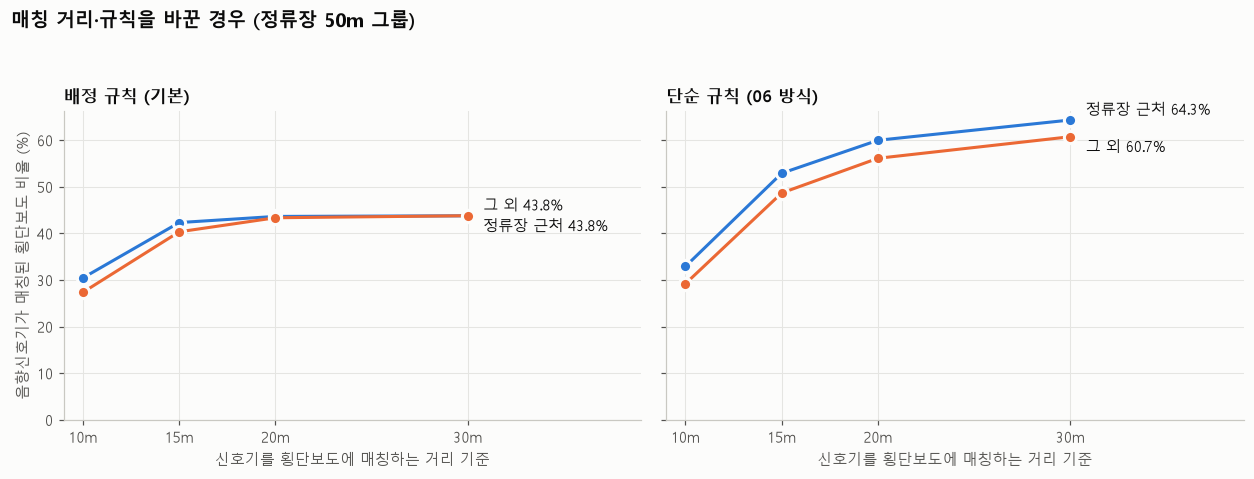

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
Rs = list(H.SIGNAL_MATCH_M)
g50 = d['정류장근처_50m'].astype(bool)
for ax, (title, key) in zip(axes, [('배정 규칙 (기본)', '음향_배정_{r}m'), ('단순 규칙 (06 방식)', '음향_단순_{r}m')]):
    a = [d.loc[g50, key.format(r=r)].mean() * 100 for r in Rs]
    b = [d.loc[~g50, key.format(r=r)].mean() * 100 for r in Rs]
    ax.plot(Rs, a, color=NEAR, linewidth=2, marker='o', markersize=8, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.plot(Rs, b, color=OTHER, linewidth=2, marker='o', markersize=8, markeredgecolor=SURFACE, markeredgewidth=2)
    gap = 2.2 if abs(a[-1] - b[-1]) < 4 else 0   # 두 값이 가까우면 라벨을 위아래로 벌린다
    up_is_near = a[-1] >= b[-1]
    ax.text(Rs[-1] + 0.8, a[-1] + (gap if up_is_near else -gap), f'정류장 근처 {a[-1]:.1f}%', color=INK, va='center', fontsize=9.5)
    ax.text(Rs[-1] + 0.8, b[-1] + (-gap if up_is_near else gap), f'그 외 {b[-1]:.1f}%', color=INK, va='center', fontsize=9.5)
    ax.set_xticks(Rs); ax.set_xticklabels([f'{r}m' for r in Rs]); ax.set_xlim(Rs[0] - 1, Rs[-1] + 9)
    ax.set_xlabel('신호기를 횡단보도에 매칭하는 거리 기준'); ax.set_title(title, fontsize=11)
axes[0].set_ylabel('음향신호기가 매칭된 횡단보도 비율 (%)'); axes[0].set_ylim(0, None)
fig.suptitle('매칭 거리·규칙을 바꾼 경우 (정류장 50m 그룹)', x=0.01, ha='left', fontweight='bold', fontsize=12.5)
plt.tight_layout(rect=(0, 0, 1, 0.93)); save(fig, '06_매칭기준_민감도.png'); plt.show()

## 5. 그림에서 보이는 것 (검정 아님)

아래는 그림과 표에 나온 숫자를 그대로 옮긴 것이다. 차이가 우연인지는 검정하지 않았으므로 판단하지 않는다.

**매칭 규칙**
- 06 방식(단순 규칙)에서는 보행등이 없는 횡단보도의 27.3%에 신호기가 매칭됐다. 신호기를 가장 가까운 횡단보도 하나에만 배정하면 11.3%로 줄었다. 06 3-4에서 의심한 "이웃 횡단보도의 신호기가 걸리는 문제"가 실제로 있었고, 배정 규칙이 이를 상당 부분 줄인다. 이 노트북은 배정 규칙 15m를 기본으로 쓴다.
- 좌표가 있는 신호기 16,847개 중 15,555개(92.3%)는 15m 안에 횡단보도가 있다. 나머지 1,292개는 매칭에 쓰이지 않는다.
- 신호기의 21.5%(4,604개)는 좌표가 없어 매칭 자체에서 빠졌다. 실제 매칭 비율은 이보다 높을 수 있다.

**그룹 크기와 위치**
- 50m 기준으로 정류장 근처 9,716개, 그 외 12,055개. 30m와 100m에서도 두 그룹이 모두 충분히 크다(작은 쪽이 4,903개, 5,204개).
- 지도에서 정류장 근처 비중은 지역별로 차이가 크다. 1km 칸 단위로 봐도 옅은 칸과 진한 칸이 섞여 있다.

**그룹별 매칭 비율 (배정 규칙, 15m)**
- 50m 기준: 정류장 근처 42.3%, 그 외 40.3% (차이 2.0%p).
- 기준 거리를 바꾸면 차이의 방향과 크기가 달라진다. 30m는 근처가 2.7%p 낮고, 100m는 7.6%p 높고, 50m에서 마을버스 정류소를 빼면 6.2%p 높다. 50m 하나의 결과로 방향을 말하기 어렵다.
- 정류소까지 거리 구간별로 보면 0~10m 28.1%(n=388), 10~25m 39.1%, 25~50m 44.9%, 50~75m 45.5%, 75~100m 41.8%, 100~150m 37.0%, 150m 이상 33.4%다. 50m를 경계로 뚜렷하게 갈리는 모양이 아니고, 가장 가까운 칸과 가장 먼 칸이 낮은 산 모양이다.

**자치구별**
- 자치구 안에서 비교하면 정류장 근처가 그 외보다 높은 자치구가 25개 중 20개다. 자치구별 차이를 횡단보도 수로 가중평균하면 2.8%p로, 서울 전체 차이(2.0%p)보다 약간 크다.
- 자치구마다 정류장 근처 비중과 전체 매칭 비율이 다르다. 25개 자치구에서 두 값의 순위 상관은 -0.30(약한 음의 관계, 기술통계)이다. 예를 들어 동작구는 근처 비중 63%에 매칭 비율 33.7%, 도봉구는 60%에 36.1%이고, 중구는 29%에 42.7%다. 다만 서초구(43%, 33.6%)나 강서구(37%, 52.7%)처럼 이 경향에서 벗어나는 자치구도 많다. 자치구를 섞어 비교하면 이런 차이가 그룹 비교에 끼어들 수 있어서 자치구를 통제하려는 것이다.
- 강서구는 반대 방향으로 크게 다르다(그 외 57%, 근처 45%). 원인은 확인하지 않았다.

**매칭 거리·규칙에 따른 차이**
- 배정 규칙에서는 매칭 거리를 20m, 30m로 늘리면 두 그룹이 거의 같아진다(30m에서 둘 다 43.8%). 단순 규칙에서는 30m에서도 근처가 3.6%p 높게 남는다. 그룹 간 차이의 크기가 매칭 규칙에 따라 달라진다.

**다음 단계에서 정할 것**
1. 카이제곱 검정과 오즈비, 자치구 통제(층화 또는 로지스틱), `교차로관리번호` 단위 군집.
2. 기준 거리(30·50·100m)와 매칭 거리(10·15·20·30m), 마을버스 제외를 민감도 분석으로 함께 볼지.
3. 위 관찰에서 나온 것(자치구 통제 필요, 거리 구간별 모양, 기준 거리에 따른 방향 변화)은 이 데이터를 보고 알게 된 것이므로, 검정에서 "탐색" 결과임을 표시한다.

**한계**
- 비율은 "전체 횡단보도 중 신호기가 매칭된 비율"이다. 신호기를 달 수 없는 보행등 없는 횡단보도도 분모에 들어 있다.
- 신호기 좌표 없음 21.5%와 2026-05-28 이후 설치분 누락은 두 그룹 모두에 영향을 주지만, 그룹별로 같은 정도인지는 확인하지 않았다.
- 도로 폭·차로 수·정류소 이용자 수는 통제하지 못한다.